## Feature Transformation

### Function transformer

log transform<br>
reciprocal transform<br> 
square root transform

### Power Transformer

Box-Cox Transform<br>
Yoe-Johnson Transform

### What happen when we use this transformation

the distribution of data i.e PDF (probability density function) convert into normal function or normal distribution <br> normal distribution make calculation easy around itself

### How to find if data is normal ?

1. using seaborn diskplot plotting if its in single wave then good 
2. using pandas skew() function if its 0 then normal either negative or other then not 
3. QQplot reliable method to find normal distribution is there or not

## Log Transform 

if we want to use log transform then we find log of all the values , so for example we take<br>
Age<br>
23<br>45<br>56<br>
so the data here is not normal , so if we find the log of all the values then it will be converted to values that can be compared <br>
it convert the additative scale to multiplacative scale <br>
through this the performance of the linear model increases 

### When to use 

Will not work on negative values <br>
if we have right skew data and we apply log transform then it bring it into center, so we can use it on right skew data<br>

## Other Transform

Reciprocal 1/x <br>
large values will become small and vice versa

square x^2<br>
used in left skwed data 

sqrt underroot x

use all the transformer and select the one giving the best result

In [52]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import FunctionTransformer,PowerTransformer
from sklearn.compose import ColumnTransformer

In [49]:
df = pd.read_csv("train.csv",usecols=['Age','Fare','Survived'])

In [50]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\rajpr\AppData\Local\Temp\ipykernel_3956\694922604.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].mean(),inplace=True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [51]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [30]:
X= df.iloc[:,1:3]
Y=df.iloc[:,0]

In [31]:
X_train ,X_test ,Y_train,Y_test =train_test_split(X,Y,test_size=0.2,random_state=42)

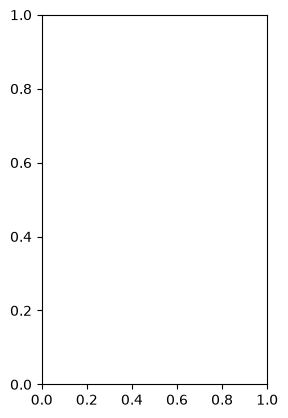

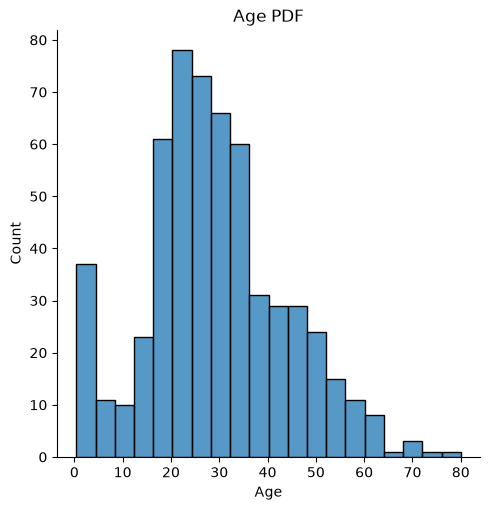

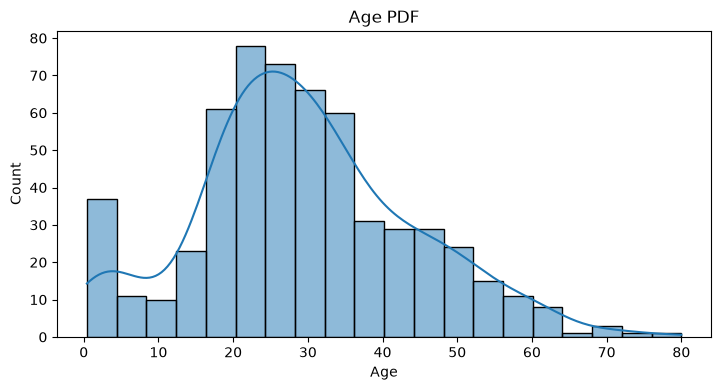

Text(0.5, 1.0, 'Age QQ plot')

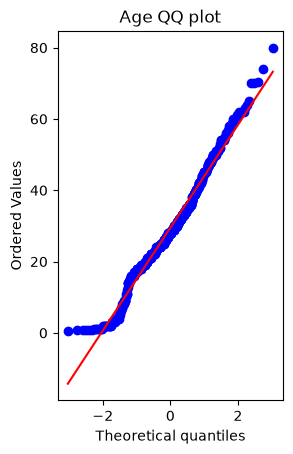

In [32]:
plt.Figure(figsize=(14,4))
plt.subplot(121)
sns.displot(X_train['Age'])
plt.title("Age PDF")
plt.figure(figsize=(14, 4))

plt.subplot(121)
sns.histplot(X_train['Age'].dropna(), kde=True)
plt.title("Age PDF")

plt.tight_layout()
plt.show()
plt.subplot(122)
stats.probplot(X_train['Age'].dropna(), dist='norm', plot=plt)
plt.title("Age QQ plot")

In [33]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [39]:
df.isna().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [47]:
clf.fit(X_train,Y_train)
clf2.fit(X_train,Y_train)

y_pre = clf.predict(X_test)
y_pre2 = clf2.predict(X_test)

print("Accuracy LR ",accuracy_score(Y_test,y_pre))
print("Accuracy DT ",accuracy_score(Y_test,y_pre2))



ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Box Cox transform <br>
only work on positive values greater then 0


### Yoe - Johnson transform<br>
adjusted version of box cox , works on negative values too

In [53]:
df = pd.read_csv("concrete_data.csv")
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [54]:
df.shape

(1030, 9)

In [55]:
df.isna().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [56]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [57]:
X = df.drop(columns=['Strength'])
Y = df.iloc[:,-1]

In [58]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [59]:
#linearregression without any transformation

lr =LinearRegression()
lr.fit(X_train,Y_train)

y_pred = lr.predict(X_test)

r2_score(Y_test,y_pred)

0.6275531792314848

In [60]:
# cross checking with cross val score

lr = LinearRegression()

np.mean(cross_val_score(lr,X,Y,scoring='r2'))

np.float64(0.4609940491662864)

In [66]:
# with transformation

pt= PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_col_lambda':pt.lambdas_})

,cols,box_col_lambda
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [67]:
lr =LinearRegression()
lr.fit(X_train_transformed,Y_train)

y_pred = lr.predict(X_test_transformed)

r2_score(Y_test,y_pred)

0.8047825008078886